In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Actividades

Mendoza Hernández Carlos Emiliano

#### Actividad 1. Usando el dataset **vehicles.csv** realizar las siguientes visualizaciones:

1. Visualizar el gasto de combustible en autopista en km/l para cada tipo de vehículo, dependiendo de la cantidad de cilindros del automóvil. Donde el tipo de automóvil está dado por la columna **VClass**, el gasto de combustible está dado por la columna **UHighway** en millas por galón y finalmente el número de cilindros del automóvil se encuentra en la columna **cylinders**. Elegir una forma de token diferente para cada tipo de automóvil.

**Preprocesamiento de datos**

In [2]:
# Cargamos el dataset con las columnas necesarias y revisamos los últimos registros
vehicles_df = pd.read_csv('vehicles.csv', usecols=['make', 'year', 'cylinders', 'VClass', 'UHighway'])
vehicles_df.tail()

,cylinders,make,UHighway,VClass,year
47316,4.0,Subaru,37.0,Compact Cars,1993
47317,4.0,Subaru,39.0,Compact Cars,1993
47318,4.0,Subaru,34.0,Compact Cars,1993
47319,4.0,Subaru,34.0,Compact Cars,1993
47320,4.0,Subaru,29.0,Compact Cars,1993


In [3]:
# Verificamos valores únicos en la columna 'VClass'
vehicles_df['VClass'].unique()

array(['Two Seaters', 'Subcompact Cars', 'Vans', 'Compact Cars',
       'Midsize Cars', 'Large Cars', 'Small Station Wagons',
       'Midsize-Large Station Wagons', 'Small Pickup Trucks',
       'Standard Pickup Trucks', 'Special Purpose Vehicle 2WD',
       'Special Purpose Vehicles', 'Minicompact Cars',
       'Special Purpose Vehicle 4WD', 'Midsize Station Wagons',
       'Small Pickup Trucks 2WD', 'Standard Pickup Trucks 2WD',
       'Standard Pickup Trucks 4WD', 'Vans, Cargo Type',
       'Vans, Passenger Type', 'Minivan - 2WD',
       'Sport Utility Vehicle - 4WD', 'Minivan - 4WD',
       'Sport Utility Vehicle - 2WD', 'Small Pickup Trucks 4WD',
       'Special Purpose Vehicle', 'Standard Pickup Trucks/2wd',
       'Vans Passenger', 'Special Purpose Vehicles/2wd',
       'Special Purpose Vehicles/4wd', 'Small Sport Utility Vehicle 4WD',
       'Standard Sport Utility Vehicle 2WD',
       'Standard Sport Utility Vehicle 4WD',
       'Small Sport Utility Vehicle 2WD'], dtype=object

In [4]:
# Revisando valores nulos
vehicles_df['cylinders'].isna().sum(), vehicles_df['UHighway'].isna().sum(), vehicles_df['VClass'].isna().sum()

(np.int64(684), np.int64(0), np.int64(0))

In [5]:
vehicles_df.dropna(subset=['cylinders', 'UHighway', 'VClass'], inplace=True)
vehicles_df.reset_index(drop=True, inplace=True)
# Verificamos nuevamente los valores nulos
vehicles_df['cylinders'].isna().sum(), vehicles_df['UHighway'].isna().sum(), vehicles_df['VClass'].isna().sum()

(np.int64(0), np.int64(0), np.int64(0))

In [6]:
# Contamos valores con rendimiento = 0
vehicles_df['UHighway'].value_counts().get(0, 0)
# Eliminamos los registros con rendimiento = 0
vehicles_df = vehicles_df[vehicles_df['UHighway'] > 0]
vehicles_df.reset_index(drop=True, inplace=True)

In [7]:
# Definimos un diccionario de mapeo para consolidar las categorías
vclass_mapping = {
    # Vehículos de pasajeros
    'Two Seaters': 'Two Seaters',
    'Subcompact Cars': 'Subcompact Cars',
    'Compact Cars': 'Compact Cars',
    'Midsize Cars': 'Midsize Cars',
    'Large Cars': 'Large Cars',
    
    # Station Wagons
    'Small Station Wagons': 'Station Wagons',
    'Midsize-Large Station Wagons': 'Station Wagons',
    'Midsize Station Wagons': 'Station Wagons',
    
    # Pickup Trucks
    'Small Pickup Trucks': 'Small Pickup Trucks',
    'Small Pickup Trucks 2WD': 'Small Pickup Trucks',
    'Small Pickup Trucks 4WD': 'Small Pickup Trucks',
    'Standard Pickup Trucks': 'Standard Pickup Trucks',
    'Standard Pickup Trucks 2WD': 'Standard Pickup Trucks',
    'Standard Pickup Trucks 4WD': 'Standard Pickup Trucks',
    'Standard Pickup Trucks/2wd': 'Standard Pickup Trucks',
    
    # Vans
    'Vans': 'Vans',
    'Vans, Cargo Type': 'Vans',
    'Vans, Passenger Type': 'Vans',
    'Vans Passenger': 'Vans',
    'Minivan - 2WD': 'Minivans',
    'Minivan - 4WD': 'Minivans',
    
    # SUVs
    'Sport Utility Vehicle - 2WD': 'SUVs',
    'Sport Utility Vehicle - 4WD': 'SUVs',
    'Small Sport Utility Vehicle 2WD': 'SUVs',
    'Small Sport Utility Vehicle 4WD': 'SUVs',
    'Standard Sport Utility Vehicle 2WD': 'SUVs',
    'Standard Sport Utility Vehicle 4WD': 'SUVs',
    
    # Special Purpose
    'Special Purpose Vehicle': 'Special Purpose Vehicles',
    'Special Purpose Vehicle 2WD': 'Special Purpose Vehicles',
    'Special Purpose Vehicle 4WD': 'Special Purpose Vehicles',
    'Special Purpose Vehicles': 'Special Purpose Vehicles',
    'Special Purpose Vehicles/2wd': 'Special Purpose Vehicles',
    'Special Purpose Vehicles/4wd': 'Special Purpose Vehicles',
    
    # Otros
    'Minicompact Cars': 'Minicompact Cars'
}

# Aplicamos el mapeo para crear una nueva columna con las categorías consolidadas
vehicles_df['VClass_merged'] = vehicles_df['VClass'].map(vclass_mapping)

# Verificamos el resultado
vehicles_df['VClass_merged'].unique()

array(['Two Seaters', 'Subcompact Cars', 'Vans', 'Compact Cars',
       'Midsize Cars', 'Large Cars', 'Station Wagons',
       'Small Pickup Trucks', 'Standard Pickup Trucks',
       'Special Purpose Vehicles', 'Minicompact Cars', 'Minivans', 'SUVs'],
      dtype=object)

In [8]:
# Convertir millas/galón a km/litro (factor de conversión: 1 mpg = 0.425144 km/l)
vehicles_df['UHighway_kmpl'] = vehicles_df['UHighway'] * 0.425144
vehicles_df['UHighway_kmpl'] = vehicles_df['UHighway_kmpl'].round(1)
# Filtro para la primera grafica
vehicles_f1 = vehicles_df[['cylinders', 'UHighway_kmpl', 'VClass_merged']]
vehicles_f1.tail()

,cylinders,UHighway_kmpl,VClass_merged
46607,4.0,15.7,Compact Cars
46608,4.0,16.6,Compact Cars
46609,4.0,14.5,Compact Cars
46610,4.0,14.5,Compact Cars
46611,4.0,12.3,Compact Cars


**Gráfica**

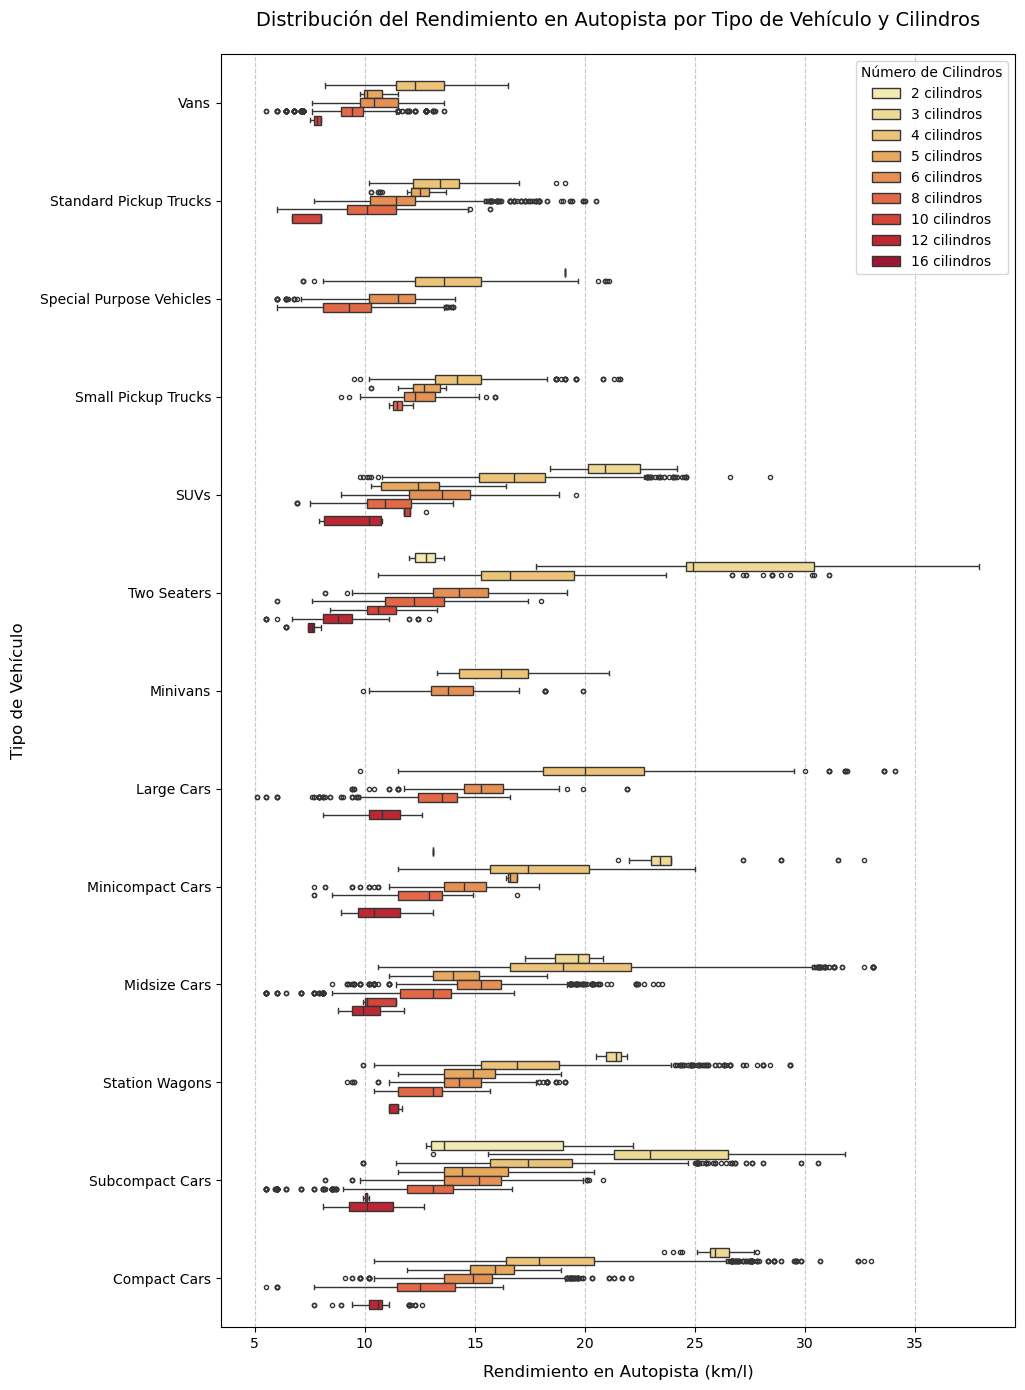

In [9]:
plt.style.use('tableau-colorblind10')
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

# Ordenar los tipos de vehículo por consumo promedio
vclass_order = vehicles_f1.groupby('VClass_merged')['UHighway_kmpl'].median().sort_values().index

# Ordenar los cilindros de menor a mayor
cylinders_order = sorted(vehicles_f1['cylinders'].unique())

# Paleta secuencial para cilindros (de claro a oscuro según aumenta el número)
palette = sns.color_palette("YlOrRd", n_colors=len(cylinders_order))

# Crear la figura
plt.figure(figsize=(12, 14))

# Crear el plot horizontal con orden específico de cilindros
ax = sns.boxplot(
    data=vehicles_f1,
    y='VClass_merged',
    x='UHighway_kmpl',
    hue='cylinders',
    hue_order=cylinders_order,
    order=vclass_order,
    dodge=True,
    width=0.8,
    linewidth=1,
    fliersize=3,
    showfliers=True,
    palette=palette
)

# Ajustes estéticos
plt.title('Distribución del Rendimiento en Autopista por Tipo de Vehículo y Cilindros', pad=20)
plt.xlabel('Rendimiento en Autopista (km/l)', labelpad=10)
plt.ylabel('Tipo de Vehículo', labelpad=10)
plt.grid(True, axis='x', linestyle='--', alpha=0.7)

handles, _ = ax.get_legend_handles_labels()
plt.legend(
    handles[:len(cylinders_order)],
    [f'{int(cyl)} cilindros' for cyl in cylinders_order],
    title='Número de Cilindros',
    loc='upper right',
    frameon=True
)

plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

**Nota:** Considero que son demasiadas categorías para el tipo de vehículo, aun después de reducir el número de categorias. Esto causó problemas para la visualización, ya que no se podían distinguir los diferentes tipos de vehículos. Por lo tanto, decidí hacer la distinción entre los tipos de vehiculos con base en la cantidad de cilindros.

2. Mostrar una comparación entre las marcas (BMW, Chevrolet, Ford, Honda, Mazda, Subaru, Volkswagen y Volvo) donde se ejemplifique dependiendo del tipo de cilindrada del vehículo cuál es su consumo de combustible en autopista km\l. Ocupe distintos colores para las marcas. Nota: use las paletas de colores vistas en clase.

In [10]:
# Filtro para la segunda grafica
make_list = ['BMW','Chevrolet', 'Ford', 'Honda', 'Mazda', 'Subaru', 'Volkswagen', 'Volvo']
vehicles_f2 = vehicles_df[vehicles_df['make'].isin(make_list)][['make', 'UHighway_kmpl', 'cylinders']]
vehicles_f2.reset_index(drop=True, inplace=True)
vehicles_f2['make'].unique()

array(['Subaru', 'Volkswagen', 'Volvo', 'BMW', 'Chevrolet', 'Ford',
       'Mazda', 'Honda'], dtype=object)

**Gráfica**

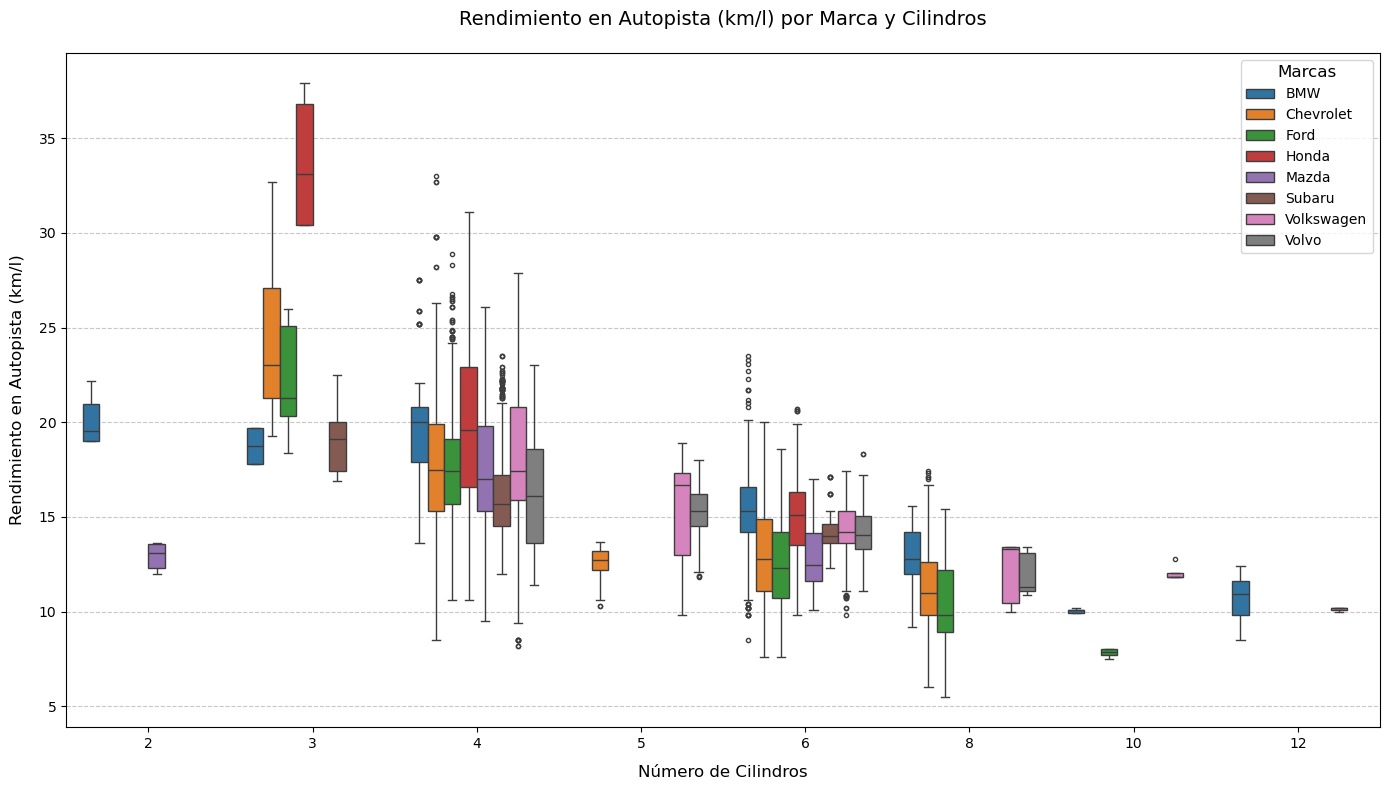

In [11]:
# Configuración de estilo
plt.rcParams['legend.title_fontsize'] = 12

# Paleta categórica distintiva (seaborn 'tab10')
brand_palette = sns.color_palette("tab10", n_colors=len(make_list))
brand_palette = dict(zip(make_list, brand_palette))

# Ordenar cilindros de menor a mayor
cylinders_order = sorted(vehicles_f2['cylinders'].unique())
cylinders_int = [int(cyl) for cyl in cylinders_order]

# Crear figura
plt.figure(figsize=(14, 8))

ax = sns.boxplot(
    data=vehicles_f2,
    x='cylinders',
    y='UHighway_kmpl',
    hue='make',
    hue_order=make_list,
    order=cylinders_order,
    palette=brand_palette,
    width=0.8,
    linewidth=1,
    fliersize=3,
    showfliers=True,
    dodge=True
)

# Ajustar ticks del eje x a valores enteros
plt.xticks(ticks=range(len(cylinders_int)), labels=cylinders_int)

# Ajustes estéticos
plt.title('Rendimiento en Autopista (km/l) por Marca y Cilindros', pad=20)
plt.xlabel('Número de Cilindros', labelpad=10)
plt.ylabel('Rendimiento en Autopista (km/l)', labelpad=10)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Leyenda mejorada
handles, labels = ax.get_legend_handles_labels()
plt.legend(
    handles[:len(make_list)],
    labels[:len(make_list)],
    title='Marcas',
    loc='upper right',
    frameon=True
)

plt.tight_layout()
plt.show()

3. Responda las siguientes preguntas de forma visual
    1. ¿Son los automóviles de modelo más reciente más eficientes que los antiguos?
    2. ¿Cuáles son las 3 marcas que son más eficientes en el consumo de combustible y cuáles son las 3 marcas menos eficientes?

In [12]:
# Filtro para la tercera grafica
vehicles_f3 = vehicles_df[['year', 'UHighway_kmpl']]

**Gráfica**

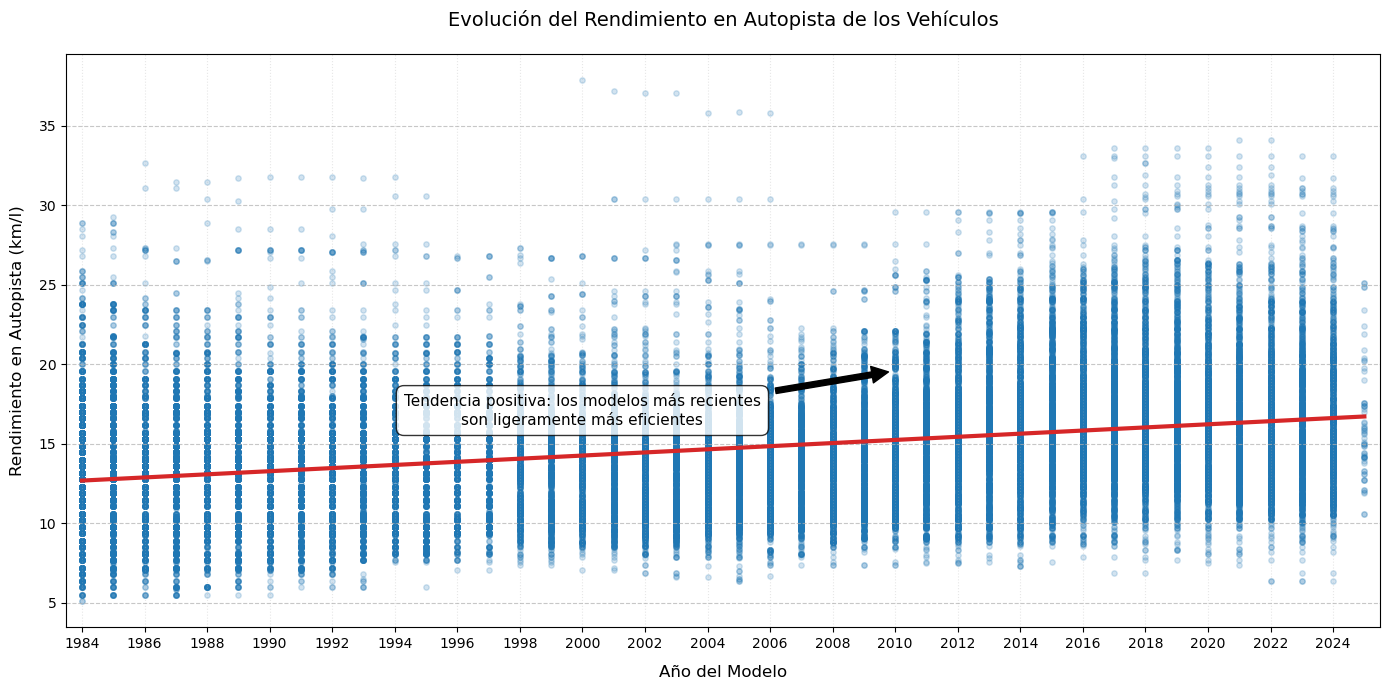

In [13]:
plt.rcParams.update({
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'font.family': 'DejaVu Sans'
})

# Crear figura
plt.figure(figsize=(14, 7))

# Gráfico de regresión
ax = sns.regplot(
    data=vehicles_f3,
    x='year',
    y='UHighway_kmpl',
    scatter_kws={'alpha': 0.2, 'color': '#1f77b4', 's': 15},
    line_kws={'color': '#d62728', 'linewidth': 3},
    ci=95
)

# Configurar ticks anuales
min_year = int(vehicles_f3['year'].min())
max_year = int(vehicles_f3['year'].max())
ax.set_xticks(range(min_year, max_year + 1, 2))

# Ajustar gridlines para coincidir con los ticks
ax.xaxis.set_minor_locator(plt.NullLocator())  # Eliminar ticks menores
plt.grid(True, axis='x', which='major', linestyle=':', alpha=0.3)

# Ajustes estéticos
plt.title('Evolución del Rendimiento en Autopista de los Vehículos', pad=20)
plt.xlabel('Año del Modelo', labelpad=10)
plt.ylabel('Rendimiento en Autopista (km/l)', labelpad=10)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Anotación de tendencia
plt.annotate('Tendencia positiva: los modelos más recientes\nson ligeramente más eficientes',
             xy=(2010, vehicles_f3['UHighway_kmpl'].quantile(0.9)),
             xytext=(2000, vehicles_f3['UHighway_kmpl'].quantile(0.7)),
             arrowprops=dict(facecolor='black', shrink=0.05),
             ha='center', fontsize=11, bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.8))

margin = 0.5
plt.xlim(min_year - margin, max_year + margin)

plt.tight_layout()
plt.show()

In [14]:
# Filtro para la cuarta grafica
vehicles_f4 = vehicles_df[['make', 'UHighway_kmpl']]
# Calcular eficiencia promedio por marca
make_efficiency = vehicles_f4.groupby('make')['UHighway_kmpl'].median().sort_values()

# Seleccionar top 3 y bottom 3
top_3 = make_efficiency.nlargest(3)
bottom_3 = make_efficiency.nsmallest(3)[::-1]
combined = pd.concat([top_3, bottom_3])

**Gráfica**

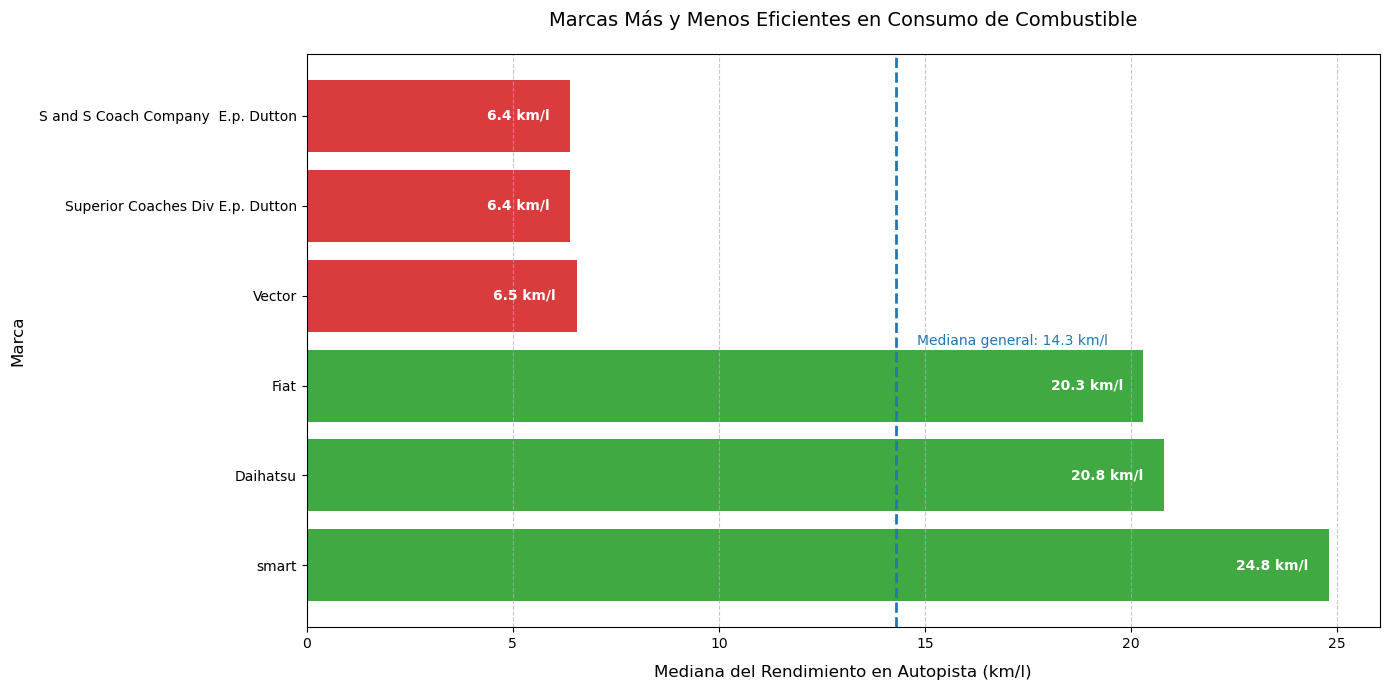

In [15]:
# Crear figura
plt.figure(figsize=(14, 7))

# Gráfico de barras
colors = ['#2ca02c']*3 + ['#d62728']*3  # Verde para eficientes, rojo para menos eficientes
bars = plt.barh(combined.index, combined.values, color=colors, alpha=0.9)

# Añadir valores en las barras
for bar in bars:
    width = bar.get_width()
    plt.text(width - 0.5, bar.get_y() + bar.get_height()/2,
             f'{width:.1f} km/l',
             ha='right', va='center', color='white', fontweight='bold')

# Línea de referencia (media general)
overall_median = vehicles_f4['UHighway_kmpl'].median()
plt.axvline(overall_median, color='#1f77b4', linestyle='--', linewidth=2)
plt.text(overall_median + 0.5, 2.5, f'Mediana general: {overall_median:.1f} km/l',
         color='#1f77b4', va='center')

# Ajustes estéticos
plt.title('Marcas Más y Menos Eficientes en Consumo de Combustible', pad=20)
plt.xlabel('Mediana del Rendimiento en Autopista (km/l)', labelpad=10)
plt.ylabel('Marca', labelpad=10)
plt.grid(True, axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### Actividad 2. A partir del dataset en el fichero *"Canada.xls"*, use la hoja de Excel nombrada *"Canada by Citizenship"*. Este fichero contiene datos de migración hacia Canadá desde diferentes países de los 5 continentes (periodo 1980 - 2013).

In [16]:
df_canada = pd.read_excel('Canada.xls', sheet_name='Canada by Citizenship (2)')
df_canada.tail()

,Type,Coverage,OdName,AREA,AreaName,REG,RegName,DEV,DevName,1980,...,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013
191,Immigrants,Foreigners,Western Sahara,903,Africa,912,Northern Africa,902,Developing regions,0,...,0,0,1,0,0,0,0,0,0,0
192,Immigrants,Foreigners,Yemen,935,Asia,922,Western Asia,902,Developing regions,1,...,124,161,140,122,133,128,211,160,174,217
193,Immigrants,Foreigners,Zambia,903,Africa,910,Eastern Africa,902,Developing regions,11,...,56,91,77,71,64,60,102,69,46,59
194,Immigrants,Foreigners,Zimbabwe,903,Africa,910,Eastern Africa,902,Developing regions,72,...,1450,615,454,663,611,508,494,434,437,407
195,Immigrants,Foreigners,Unknown,999,World,999,World,999,World,44000,...,3739,4785,4583,4348,4197,3402,3731,2554,1681,1484


1. Construya un gráfico de área que permita ver las proporciones de migración por año.

In [17]:
# Seleccionar las columnas necesarias
df_regions = df_canada[df_canada["RegName"] != "World"].groupby("RegName").sum(numeric_only=True).loc[:, 1980:2013]
df_regions = df_regions[::-1]

# Convertir a proporciones
df_regions_percentage = df_regions.div(df_regions.sum(axis=0), axis=1) * 100

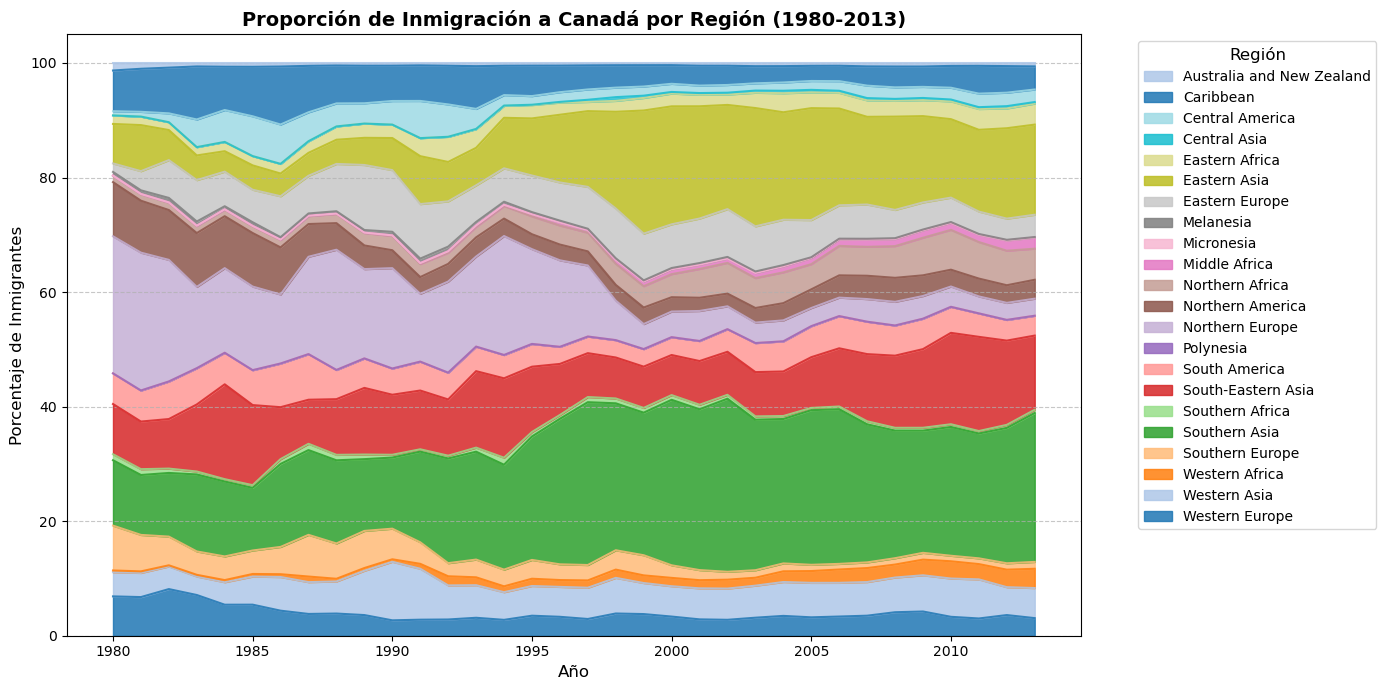

In [18]:
# Obtener una paleta de colores categórica de 22 colores
palette = sns.color_palette("tab20", 22)

# Crear gráfico de áreas apiladas
ax = df_regions_percentage.T.plot(kind="area", color=palette, alpha=0.85, figsize=(14, 7))

# Ajustes del gráfico
plt.title("Proporción de Inmigración a Canadá por Región (1980-2013)", fontsize=14, fontweight="bold")
plt.xlabel("Año", fontsize=12)
plt.ylabel("Porcentaje de Inmigrantes", fontsize=12)

# Invertir el orden de las leyendas
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title="Región", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=10)

plt.yticks(fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

2. Muestre mediante mapas coropléticos la evolución de cantidad de migrantes que ingresaron a Canadá, en tres décadas diferentes: 1980-1989, 1990-1999 y 2000-2009.

In [19]:
# Filtrar las columnas necesarias y eliminar "World"
df_countries = df_canada[df_canada["RegName"] != "World"].copy()

# Sumar la cantidad de migrantes por país en cada década
df_countries["1980s"] = df_countries.loc[:, 1980:1989].sum(axis=1)
df_countries["1990s"] = df_countries.loc[:, 1990:1999].sum(axis=1)
df_countries["2000s"] = df_countries.loc[:, 2000:2009].sum(axis=1)

# Seleccionar solo las columnas necesarias
df_countries = df_countries[["OdName", "1980s", "1990s", "2000s"]]

# Preparar datos en formato largo para Plotly
df_long = df_countries.melt(id_vars=['OdName'], 
                            value_vars=['1980s', '1990s', '2000s'],
                            var_name='Década', 
                            value_name='Inmigrantes')
df_long.head()

,OdName,Década,Inmigrantes
0,Afghanistan,1980s,3693
1,Albania,1980s,9
2,Algeria,1980s,1271
3,American Samoa,1980s,3
4,Andorra,1980s,2


In [20]:
# Crear el mapa animado
fig = px.choropleth(df_long,
                    locations="OdName",
                    locationmode='country names',
                    color="Inmigrantes",
                    animation_frame="Década",
                    color_continuous_scale="YlOrRd",
                    range_color=(0, df_long['Inmigrantes'].quantile(0.95)),
                    height=600,
                    width=1030,
                    projection="natural earth")

fig.update_layout(
    title={
        'text': "<b>Evolución de Inmigración a Canadá (1980-2009)</b>",
        'font': {'color': 'black', 'size': 18},
        'x': 0.5,
        'xanchor': 'center'
    }
)

# Ajustes estéticos
fig.update_layout(
    margin={"r":0,"t":40,"l":0,"b":0},
    coloraxis_colorbar=dict(title="Inmigrantes"),
    title_x=0.5,
    title_font_size=20,
    geo=dict(
        showframe=True,
        showcoastlines=True,
        landcolor='lightgray'
    )
)

# Ajustar la velocidad de animación
fig.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 5000
fig.show()

In [21]:
# Crear figura con subplots especificando tipo de mapa
fig = make_subplots(
    rows=1, cols=3,
    specs=[[{'type': 'choropleth'}, {'type': 'choropleth'}, {'type': 'choropleth'}]],
    subplot_titles=("<b>1980-1989</b>", "<b>1990-1999</b>", "<b>2000-2009</b>"),
    horizontal_spacing=0.015
)

# Añadir cada mapa manualmente
for i, decade in enumerate(['1980s', '1990s', '2000s']):
    fig.add_trace(
        go.Choropleth(
            locations=df_countries['OdName'],
            locationmode='country names',
            z=df_countries[decade],
            colorscale='YlOrRd',
            zmin=0,
            zmax=df_long['Inmigrantes'].quantile(0.95),
            colorbar=dict(title='Inmigrantes', len=0.7)
        ),
        row=1, col=i+1
    )

# Configuración unificada de los mapas
fig.update_geos(
    scope='world',
    showframe=True,
    showcoastlines=True,
    landcolor='lightgray',
    projection_type='natural earth'
)

# Diseño final
fig.update_layout(
    title_text="<b>Evolución de Inmigración a Canadá (1980-2009)</b>",
    title_font=dict(color='black', size=24),
    title_x=0.5,
    margin={"r":10,"t":100,"l":10,"b":0},
    height=500,
    width=1400,
    showlegend=True
)

# Ajustar títulos de década
fig.update_annotations(font_size=14, font_color='black')
fig.show()